## Preliminaries

This code requires a modified version of the [`terratorch` repository](https://github.com/drobiu/terratorch/tree/fixlip)

Additionally, we will use the `plotting_utils.py` file from the `Terramind` repository for easier plotting

In [2]:
import sys

import matplotlib.pyplot as plt
import src

import torch
import torch.nn.functional as F
import rioxarray as rxr
import matplotlib.pyplot as plt
from plotting_utils import s2_to_rgb, plot_s2, lulc_to_rgb, s1_to_rgb, plot_s1
from terratorch.registry import FULL_MODEL_REGISTRY
from glob import glob

# Select device
if torch.cuda.is_available():
    device = 'cuda'    
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

## Data loading

Here, we're loading the data for a sample from the [`sen1floods11`](https://github.com/cloudtostreet/Sen1Floods11) dataset. If needed, download the dataset using `gsutil -m rsync -r gs://sen1floods11 /YOUR/LOCAL/DIRECTORY/HERE`.

The images will be cropped to the TerraMind input size of 224x224.

In [4]:
classes = ['unknown', 'water', 'trees', 'flooded vegetation', 'crops', 'built area', 'bare ground', 'snow/ice', 'clouds', 'rangeland']
l = 0
s = 224
img_s2 = '../data/sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand/Bolivia_129334_S2Hand.tif'
img_s1 = '../data/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_129334_S1Hand.tif'
data_s2 = rxr.open_rasterio(img_s2).values[:, l:l+s, l:l+s]
data_s1 = rxr.open_rasterio(img_s1).values[:, l:l+s, l:l+s]
label = rxr.open_rasterio('../data/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_23014_LabelHand.tif').values[:, l:l+s, l:l+s]

input_image_s2 = torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0)
input_image_s1 = torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)
input_text = torch.tensor([[-20, 15]]).to(device)

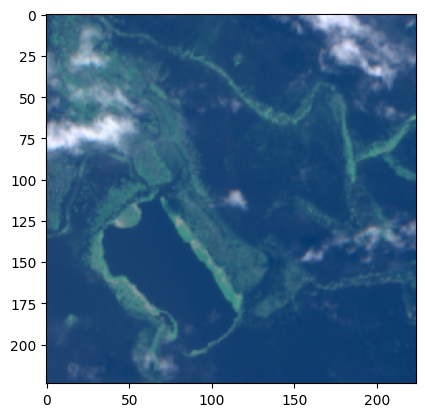

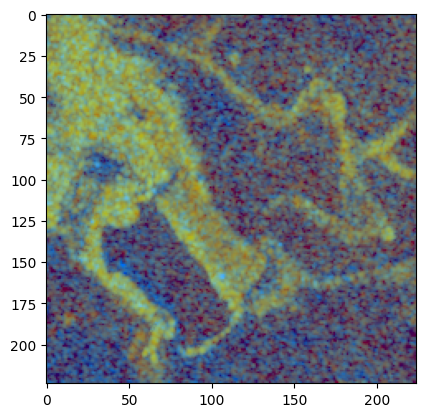

In [ ]:
# Visualize the input
plt.imshow(s2_to_rgb(input_image_s2.detach().cpu().numpy()))
plt.show()
plt.imshow(s1_to_rgb(input_image_s1.detach().cpu().numpy()))

## Initialize the model

We will initialize a model for predicting LULC classes from the multimodal Sentinel-1 and Sentinel-2 input.

In [6]:
# Define the output from S2L2A, S1GRD, S1RTC, DEM, LULC, and NDVI
output_modalities = ['LULC']

# Build model
model = FULL_MODEL_REGISTRY.build(
    'terramind_v1_small_generate',
    modalities=['S2L1C', 'S1GRD'],
    output_modalities=output_modalities,
    pretrained=True,
    standardize=True,
    timesteps=100,  # Number of diffusion steps
)

model = model.to(device)
lulc = model({'S2L1C': input_image_s2.repeat(4, 1, 1, 1), 'S1GRD': input_image_s1.repeat(4, 1, 1, 1)})['LULC']

2026-07-14 14:32:52,105 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-Tokenizer-LULC/resolve/main/TerraMind_Tokenizer_LULC.pt "HTTP/1.1 302 Found"
2026-07-14 14:32:52,106 - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-14 14:32:52,847 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


array([0.0000000e+00, 1.8772420e-01, 3.9042570e-02, 4.5863560e-01,
       1.1658961e-03, 0.0000000e+00, 6.9754460e-05, 2.3417569e-04,
       1.0654496e-01, 2.0658283e-01], dtype=float32)

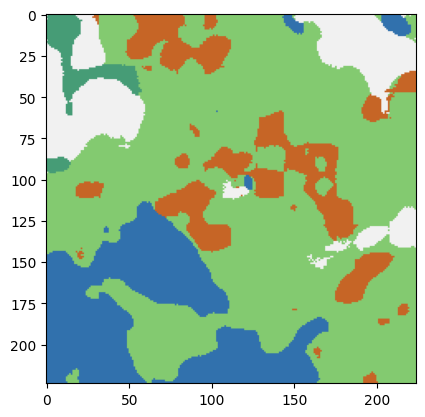

In [7]:
# Visualize LULC prediction
plt.imshow(lulc_to_rgb(lulc.mean(0).detach().cpu().numpy()))
F.one_hot(lulc.argmax(1)).float().mean((0, 1, 2)).cpu().numpy()

## Initialize the explainer

We will explain the model output with regard to class 1 - water

We set `grid_step` to 7, essentially aggregating tokens to a 2x2 grid, making the computation quicker

In [14]:
# Select the class to explain
cl = 1

game = src.game_terramind.VisionLanguageGame(
    model=model,
    inputs={'S2L1C': input_image_s2, 'S1GRD': input_image_s1}, 
    modalities={'S2L1C': 'image', 'S1GRD': 'image'}, 
    mask_names={'S2L1C': 'untok_sen2l1c@224', 'S1GRD': 'untok_sen1grd@224'},
    batch_size=16,
    cl=cl,
    grid_step=7,
)

fixlip = src.fixlip.FIxLIP(
    n_players_modalities=game.n_players_image | game.n_players_text, 
    max_order=2,
    p=0.5, # weight
    mode="banzhaf",
    random_state=0
)

# Print the interactions
src.utils.set_seed(0)
interaction_values = fixlip.approximate_crossmodal(game, budget=2**15)
print(interaction_values)

100%|██████████| 1/1 [00:04<00:00,  4.83s/it]

InteractionValues(
    index=FWBII, max_order=2, min_order=0, estimated=False, estimation_budget=256,
    n_players=8, baseline_value=6.776548120771622,
    Top 10 interactions:
        (): 6.776548120771622
        (6,): 6.0723917108698515
        (2,): 2.478033183142543
        (7,): 1.3977520117041422
        (3, 4): -0.9638504312169971
        (1, 6): -1.0827796190715162
        (1,): -1.4656011243350804
        (0,): -1.4693896393291652
        (3, 6): -2.083160576337832
        (2, 6): -3.560478368002805
)


/var/folders/8b/6b2t7b315p311388qfgc6jlw0000gn/T/ipykernel_10786/3258709167.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


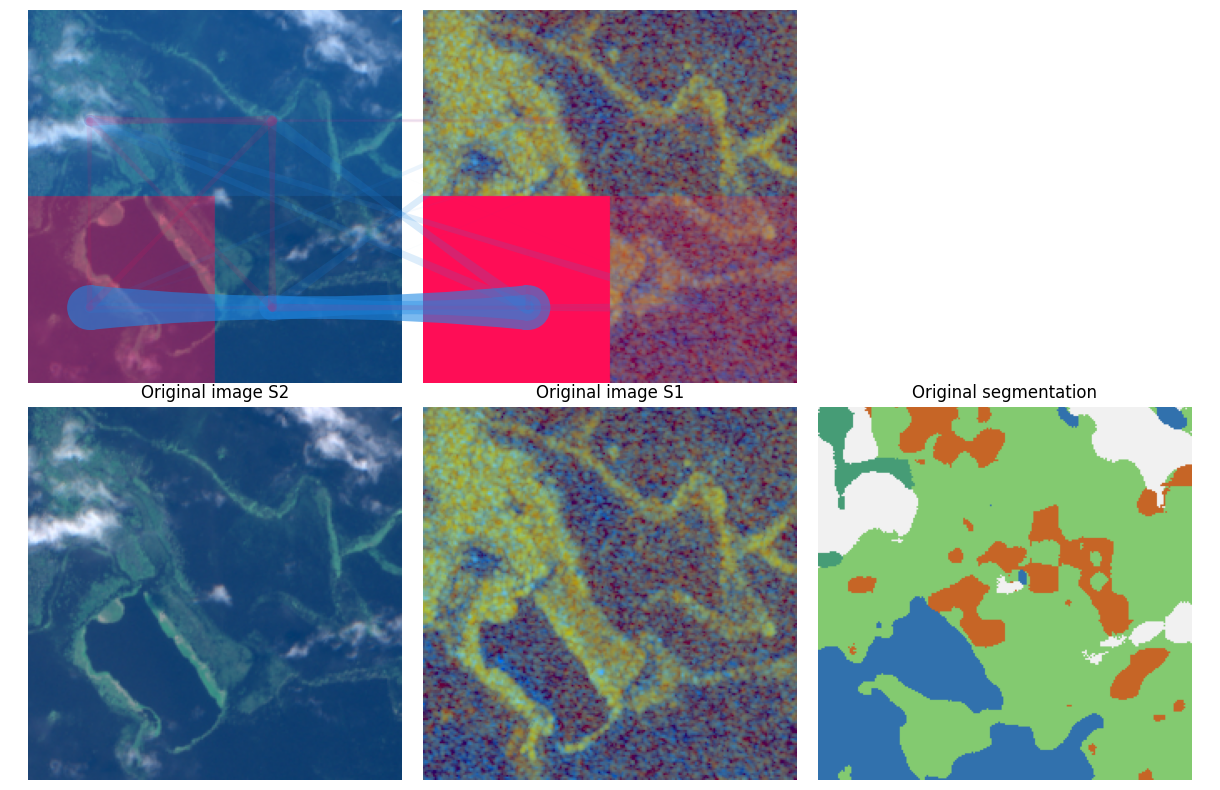

In [15]:
n_players_image = game.n_players_image
n_players_text = game.n_players_text
# fig, axs = plt.subplots(1, 2, figsize=(12, 4))
fig = plt.figure(figsize=(12, 8))
ax1 = plt.subplot(2,3,1)
ax2 = plt.subplot(2,3,2)
ax3 = plt.subplot(2,3,4)
ax4 = plt.subplot(2,3,5)
ax5 = plt.subplot(2,3,6)
axs = [ax1, ax2, ax3, ax4, ax5]


orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'S1GRD': torch.tensor(data_s1, dtype=torch.float, device=device).unsqueeze(0)}
# orig = {'S2L1C': torch.tensor(data_s2, dtype=torch.float, device=device).unsqueeze(0), 'Coords': input_text}
tokenized = model.forward_tokenizer(orig)
out = model.forward_tokenized(tokenized, orig)

src.plot.plot_image_and_text_together(
    img={'S2L1C': s2_to_rgb(input_image_s2), 'S1GRD': s1_to_rgb(input_image_s1)},
    # text=tokenized['coords']['tensor'].cpu().detach().numpy()[0].astype(str)[:-1],
    # text=input_text.cpu().detach().numpy()[0].astype(str),
    text=[],
    image_players=n_players_image,
    iv=interaction_values,
    plot_interactions=True,
    top_k=50,
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=12,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=True,
    max_value=None,
    axes=axs[:2]
)
# fig.suptitle(f"Attributions class {classes[cl]}")
# plt.show()
# fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# out['S2L2A'].shape
# out = model(orig)
axs[4].imshow(lulc_to_rgb(lulc.mean(0).detach().cpu().numpy()))
axs[4].axis('off')
axs[4].set_title("Original segmentation")

plot_s2(data_s2, ax=axs[2])
axs[2].set_title("Original image S2")
# plt.savefig(f'figures/attributions/attribution_{img_s2.split("/")[-1][:-4]}_class_{cl}')

plot_s1(data_s1, ax=axs[3])
axs[3].set_title("Original image S1")
# plt.savefig(f'figures/attributions_multiimage/attribution_{img_s2.split("/")[-1][:-4]}_class_{cl}')
plt.tight_layout()
plt.show()